In [425]:
### TO RUN
import os

import matplotlib.pyplot as plt
import numpy as np

"Machine learning tools"
import pickle

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from src.classification.datasets import Dataset
from src.classification.utils.audio_student import AudioUtil, Feature_vector_DS
from src.classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)
from src.classification.utils.utils import accuracy



In [426]:
np.random.seed(0)

Useful functions to select, read and play the dataset sounds are provided in ``classification/utils/audio_student.py``. <br>

As for the H1, you will have to fill some short pieces of code, as well as answer some questions. We already created cells for you to answer the questions to ensure you don't forget it ;). <br>
You will find the zones to be briefly filled  with a ``### TO COMPLETE`` in the cells below.

<font size=6 color=#009999> 2. Training and Evaluating models on audio signals [~1h30-2h] </font> <br>

In [427]:
### TO RUN
dataset = Dataset()
classnames = dataset.list_classes()

print("\n".join(classnames))

background
birds
chainsaw
fire
fireworks
gunshot
handsaw
helicopter


We will only keep 5 class for this notebook:
- birds
- chainsaw
- fire
- handsaw
- helicopter

The classes used in the contest will be different.

In [428]:
dataset.remove_class("background")
dataset.remove_class("fireworks")
dataset.remove_class("gunshot")
classnames = dataset.list_classes()

print("\n".join(classnames))

birds
chainsaw
fire
handsaw
helicopter


In [429]:
### TO RUN
fm_dir = "data/feature_matrices/"  # where to save the features matrices
model_dir = "data/models/"  # where to save the models
os.makedirs(fm_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In H1, it was not made explicit what we choose as input for the classification model, a.k.a. ``feature vector`` (it was shown in the illustration). <br>
The objective is, on the transmitter side, to compute a feature vector containing enough information about the audio signal we want to classify, but not too much in order to limit the data which has to be transmitted wirelessly. This is why in H1 we implemented the ``Hz2Mel`` conversion: a very simple compression of the frequency content. <br>
The feature vector we will use here simply consists in taking the first 20 columns of the melspectrogram, corresponding to ~1s, then reshaping it as a vector. This means each feature vector contains ``400`` coefficients, with 20 columns of 20 mels each.  <br>

Once the feature vector has been recovered on the receiver side, we can apply any computation on it to guess the right class this sound belongs to. Today, we will simply reuse the simple KNN and LDA classifiers and look at what we already get. 

<font size=3 color=#FF0000> Important :</font> <br>
The analyses that follow are given as food for thoughts. They are not given as step by step improvements of the classifier.

<font size=5 color=#009999> 2.1. Creation of the dataset </font> <br>

``Feature_vector_DS`` is a class defined in ``classification/utils/audio_student.py``. <br>
The functions ``__len__`` and ``__getitem__`` are implemented, meaning you can call :
- ``len(myds)`` to get the number of sounds in it.
- ``myds[classname,j]`` to get the melspectrogram of the ``j``-th sound from class ``classname``. <br>

Two other useful functions are provided:
- ``get_audiosignal`` returning the temporal audiosignal at the specified index.
- ``display`` playing the sound and showing the associated mel-spectrogram at the specified index.

<font size=3 color=#FF0000> Important :</font> <br>
Before being able to run the cells below, you will have to reuse your functions from H1 to fill the missing lines in ``audio_student.py`` at ``###TO COMPLETE`` locations.

Moreover, you have to restart your python kernel for any change to those imported files to be taken into account. This can be done by pressing 》which stops the kernel and tries to run each cell sequentially.

In [430]:
### TO RUN

"Creation of the dataset"
myds = Feature_vector_DS(dataset, Nft=512, nmel=20, duration=950, step=np.inf)

"Some attributes..."
myds.nmel
myds.duration
myds.sr
myds.data_aug
myds.ncol


# idx = 0
# myds.display(["fire", idx], show_features=False)

20

### Questions:
The magenta boxes shown in the graph shows the part of the spectrogram that will be actually used as feature.

- Now, in the Feature_vectore_DS intialization, change the step value to 40, 20 and 1. How does this impact the dataset that will be generated?
- Analyze the pros and cons of each value.
- Where can you do your train-test split in each case?


With step=1, we notice there is overlapping between the windows. This could be helpful in theory to have an even bigger dataset but in fact we risk to suffer from overfitting due to too much data and correlated data. Step=40 is already good as we have more data and no overlapping but it appears that step=20 is the best step we can put as it maximizes the amount of data without any overlapping as we can see on the figure.

(pas sur de comprendre la 3eme qst?) No matter our step, we have to ensure the data that will be used as a feature isn't too much corrupted with noise or perturbated with other sound. At least it has to be recognizable by a human else it's likely the data will corrupt our dataset and the algorithm.


Set step back to np.inf for the rest of this notebook.

In [431]:
### TO RUN
X, y = myds.get_feature_vectors()

np.save(fm_dir + "feature_matrix_2D.npy", X)
np.save(fm_dir + "labels.npy", y)

X = np.load(fm_dir+"feature_matrix_2D.npy")
y = np.load(fm_dir+"labels.npy")

print(f"Shape of the feature matrix : {X.shape}")
print(f"Number of labels : {len(y)}")

print(
    "Remember the convention shown for the toy example, the feature vectors are arranged on the rows."
)

Shape of the feature matrix : (200, 400)
Number of labels : 200
Remember the convention shown for the toy example, the feature vectors are arranged on the rows.


You might notice that ``feature_matrix_2D.npy`` has been saved in ``data/feature_matrices/`` and can now be loaded instead of recomputing it at every run.

<font size=5 color=#009999> 2.2. First audio classification, metrics and dataset splitting </font> <br>

For now we have only prepared the dataset, it remains to feed it to the classifiers. <br>

In [432]:
### TO RUN
K = 6  # Number of neighbours for the KNN
model_knn = KNeighborsClassifier(
    n_neighbors=K, weights="distance", algorithm="auto", metric="minkowski"
)  # We explicitly write the default parameters of this KNN classifier once so that you know they exist and can be changed

model_lda = LDA(
    solver="svd",
    shrinkage=None,
    priors=None,
    n_components=None,
    store_covariance=False,
    tol=0.0001,
    covariance_estimator=None,
)  # We explicitly write the default parameters of this LDA classifier once so that you know they exist and can be changed

model_svm = SVC(
kernel="rbf", # You can change to "linear", "poly", etc.
C=1.0, # Regularization parameter
gamma="scale", # Kernel coefficient
probability=False, # If you want probabilities set True
random_state=0
)

As for the toy example, we keep the ``accuracy`` as metric and the ``confusion matrix`` as visualization. <br>

Note that here we are not especially interested in a model selection hence we only split the dataset in training and testing parts but we don't split the training set in learning/validation parts. The models are trained on the entire training set.

Shape of the training matrix : (140, 400)
Number of training labels : 140
Accuracy of KNN with fixed train/validation sets : 60.0%


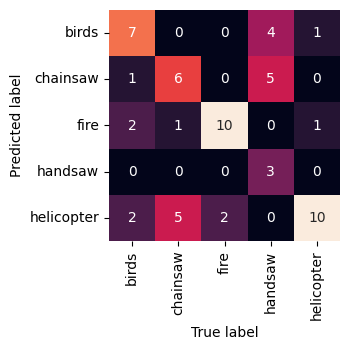

Accuracy of LDA with fixed train/validation sets : 30.0%


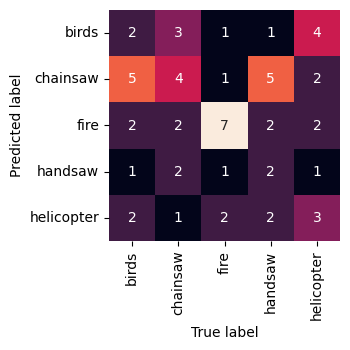

Accuracy of SVM with fixed train/validation sets : 66.7%


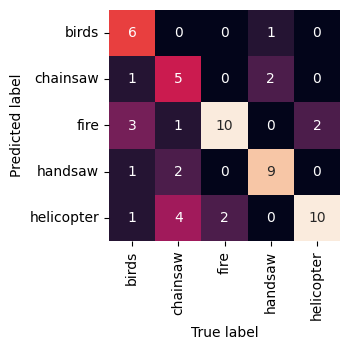

In [433]:
### TO RUN
"Shuffle then split the dataset into training and testing subsets"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)  # random_state=1
print(f"Shape of the training matrix : {X_train.shape}")
print(f"Number of training labels : {len(y_train)}")

model_knn.fit(X_train, y_train)
model_lda.fit(X_train, y_train)
model_svm.fit(X_train, y_train)

prediction_knn = model_knn.predict(X_test)
prediction_lda = model_lda.predict(X_test)
prediction_svm = model_svm.predict(X_test)
accuracy_knn = accuracy(prediction_knn, y_test)
accuracy_lda = accuracy(prediction_lda, y_test)
accuracy_svm = accuracy(prediction_svm, y_test)

print(f"Accuracy of KNN with fixed train/validation sets : {100 * accuracy_knn:.1f}%")
show_confusion_matrix(prediction_knn, y_test, classnames)
print(f"Accuracy of LDA with fixed train/validation sets : {100 * accuracy_lda:.1f}%")
show_confusion_matrix(prediction_lda, y_test, classnames)
print(f"Accuracy of SVM with fixed train/validation sets : {100 * accuracy_svm:.1f}%")
show_confusion_matrix(prediction_svm, y_test, classnames)

**Questions**: 
- What would be the expected accuracy if the label predictions were picked at random?
- What do you observe in this confusion matrix? Run again the cell above, i.e., Reapply the ``train_test_split`` and tell if your observations are robust.

TO COMPLETE

Answer the questions above

As we have 5 different labels, we should have an accuracy of 20% if we picked at random.

We can see that the fire label is the one we chose the most and handsaw the least. KNN is better

When changing the seed, the accuracy is more or less the same: our model is robust.


Play with the ``classname`` and the index ``idx`` to pick feature vectors in the dataset ``myds``, listen to the audio associated to the feature vector, and check if you would have been able to predict the right class by your own. Then compare with the prediction given by your classifier.

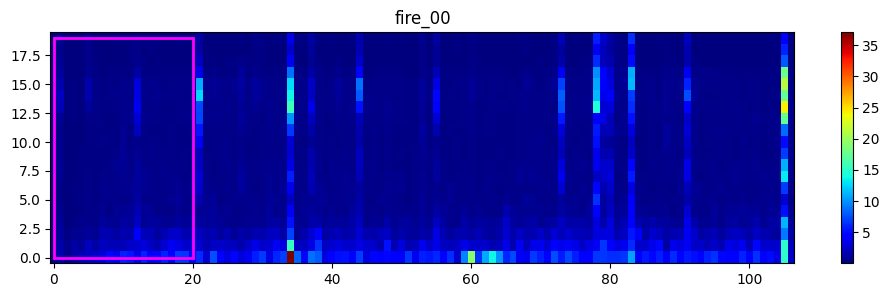

Class predicted by KNN: fire
Class predicted by LDA: fire
Class predicted by SVM: fire


In [434]:
### TO RUN
idx = 0
classname = "fire"
myds.display([classname, idx], show_features=True)

# 1) Récupérer le melspectrogram complet
mel = myds[classname, idx]           # shape ~ (nmel, ncol_full)

# 2) Adapter le melspectrogram aux features du modèle
n_features_model = model_knn.n_features_in_   # ex: 400
nmel = myds.nmel                              # ex: 20
ncol_keep = n_features_model // nmel          # ex: 20

mel_reduced = mel[:, :ncol_keep]              # shape (nmel, ncol_keep)
thisfv = mel_reduced.reshape(1, -1)           # shape (1, n_features_model)

# 3) Prédictions
prediction_knn = model_knn.predict(thisfv)
prediction_lda = model_lda.predict(thisfv)
prediction_svm = model_svm.predict(thisfv)

print("Class predicted by KNN:", prediction_knn[0])
print("Class predicted by LDA:", prediction_lda[0])
print("Class predicted by SVM:", prediction_svm[0])

Furthermore, when training a model and comparing different settings, there is a risk that we will end up choosing optimal parameters that only render good result on our specific case of training and validation set, but ``do not generalize well for additional data``. This is called ``overfitting on the validation set``. To alleviate this, we can perform ``cross-validation (CV)``. A basic approach named ``K-fold CV`` involves partitioning the dataset in ``K`` "folds" (subsets) and repetitvely do the following procedure:

- Train the model using `K-1` folds as the training data.
- Test the model using the last fold as the validation data.

The overall performance on each fold is then averaged to obtain the final performance metrics.

In [435]:
### TO RUN
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True)

accuracy_knn = np.zeros((n_splits,))
accuracy_lda = np.zeros((n_splits,))
accuracy_svm = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_train, y_train)):
    (idx_learn, idx_val) = idx
    model_knn.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_knn = model_knn.predict(X_train[idx_val])
    accuracy_knn[k] = accuracy(prediction_knn, y_train[idx_val])

    model_lda.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_lda = model_lda.predict(X_train[idx_val])
    accuracy_lda[k] = accuracy(prediction_lda, y_train[idx_val])

    model_svm.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_svm = model_svm.predict(X_train[idx_val])
    accuracy_svm[k] = accuracy(prediction_svm, y_train[idx_val])

print(f"Mean accuracy of KNN with 5-Fold CV: {100 * accuracy_knn.mean():.1f}%")
print(
    f"Std deviation in accuracy of KNN with 5-Fold CV: {100 * accuracy_knn.std():.1f}%"
)

print(f"Mean accuracy of LDA with 5-Fold CV: {100 * accuracy_lda.mean():.1f}%")
print(
    f"Std deviation in accuracy of LDA with 5-Fold CV: {100 * accuracy_lda.std():.1f}%"
)

print(f"Mean accuracy of SVM with 5-Fold CV: {100 * accuracy_svm.mean():.1f}%")
print(
    f"Std deviation in accuracy of SVM with 5-Fold CV: {100 * accuracy_svm.std():.1f}%"
)

Mean accuracy of KNN with 5-Fold CV: 46.4%
Std deviation in accuracy of KNN with 5-Fold CV: 4.5%
Mean accuracy of LDA with 5-Fold CV: 37.9%
Std deviation in accuracy of LDA with 5-Fold CV: 6.2%
Mean accuracy of SVM with 5-Fold CV: 50.7%
Std deviation in accuracy of SVM with 5-Fold CV: 6.9%


<font size=5 color=#009999> 2.3. Scale mismatch and countermeasure </font> <br>

In real conditions, you will most probably have a different scale between the feature vectors used for training (in simulation) and the ones you feed in your model to make predictions.
This scale mismatch between model training and prediction is difficult to prevent because it depends on multiple factors such as the audio source power, its distance to the microphone, the telecommunication distance. <br>

Below, we illustrate the link between the volume of the audio and its distance to the origin of the feature space. At different emission distances, the exact same sound would be heard at a different volume and the associated feature vector would be located at another position in the *feature space*. Eventually, this would result in a completely different classification, which is undesirable.

<center> <img src="figs/norms.png" alt="" width="350"/> </center>

### Questions:

- How could you avoid this dependency on the volume of the sound?
- What is represented in the hatched centered area? How would you classify feature vectors in this area?

TO COMPLETE

Answer the questions above

- Normalize the data

- Noise ? Inaudible sound ? we can't detect the sound so we're fucked ?

Play with the ``dB_mismatch`` variable here below and observe its effect on the confusion matrix.

On which part of the dataset are we computing this confusion matrix?

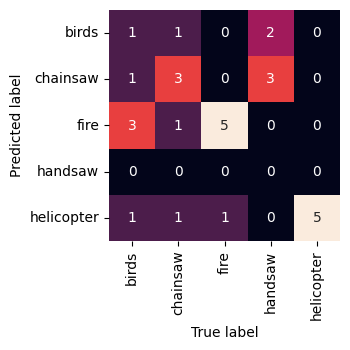

Accuracy of KNN: 50.0%


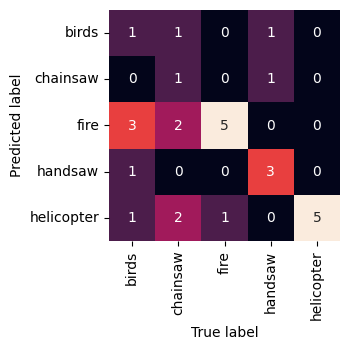

Accuracy of SVM: 53.6%


In [436]:
### TO RUN
dB_mismatch = 0  # Play with this value
X_val_scaled = X_train[idx_val] * 10 ** (-dB_mismatch / 20)

model_knn = KNeighborsClassifier(n_neighbors=10)
model_knn.fit(X_train[idx_learn], y_train[idx_learn])
prediction_knn = model_knn.predict(X_val_scaled)
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])
print(f"Accuracy of KNN: {100 * accuracy_knn:.1f}%")

model_svm = SVC()
model_svm.fit(X_train[idx_learn], y_train[idx_learn])
prediction_svm = model_svm.predict(X_val_scaled)
show_confusion_matrix(prediction_svm, y_train[idx_val], classnames)
accuracy_svm = accuracy(prediction_svm, y_train[idx_val])
print(f"Accuracy of SVM: {100 * accuracy_svm:.1f}%")

The simplest countermeasure we can think of is to normalise the feature vector (i.e. unitize its norm) prior to use, both for training and testing. Remember how this normalization could be visualized in ``hands_on_classif1_toy_student.ipynb`` <br>
Play again with the ``dB_mismatch`` variable here below and observe its effect on the confusion matrix.

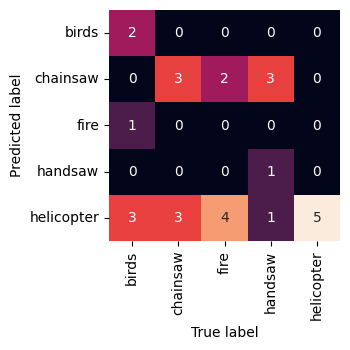

Accuracy of KNN: 39.3%


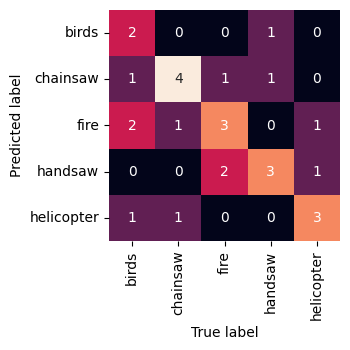

Accuracy of SVM: 53.6%


In [437]:
### TO RUN
dB_mismatch = 0  # Play with this value

X_learn_normalised = X_train[idx_learn] / np.linalg.norm(
    X_train[idx_learn], axis=1, keepdims=True
)
model_knn = KNeighborsClassifier(n_neighbors=10, weights="distance")
model_knn.fit(X_learn_normalised, y_train[idx_learn])

X_val_scaled = X_train[idx_val] * 10 ** (-dB_mismatch / 20)
X_val_normalised = X_val_scaled / np.linalg.norm(X_val_scaled, axis=1, keepdims=True)

prediction_knn = model_knn.predict(X_val_normalised)
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])
print(f"Accuracy of KNN: {100 * accuracy_knn:.1f}%")

model_svm = SVC()
model_svm.fit(X_learn_normalised, y_train[idx_learn])
prediction_svm = model_svm.predict(X_val_normalised)
show_confusion_matrix(prediction_svm, y_train[idx_val], classnames)
accuracy_svm = accuracy(prediction_svm, y_train[idx_val])
print(f"Accuracy of SVM: {100 * accuracy_svm:.1f}%")

**Question**: 
- What will happen with this normalisation countermeasure when there is no sound around the microphone? Is this desirable? How could you deal with it?

TO COMPLETE

Answer the questions above

If we normalize but there's no sound, we'll just normalize to the scale of the sound and the whole spectrogram will show very high sound at every frequency for every time.

To prevent it, we could implement a detector that doesn't perform the normalization unless a certain treshold of dB is passed for the maximum of the signal (which would correspond to the epsilon btw).

<font size=5 color=#009999> 2.4. Dimensionality reduction </font> <br>

It is sometimes good practice to reduce the dimensionality of a signal in order to get the main components of their distribution. A motivation is that usual norms behave counter-inuitively in high dimension. It also further reduces the memory cost of the feature vector. To reduce the dimensionality, we will use the ``Principal component analysis (PCA)`` proposed by sklearn. See the [associated Wikipedia page](https://en.wikipedia.org/wiki/Principal_component_analysis). Recall: the PCA consists in reducing the dimensionality of data vectors encoded in $\boldsymbol X \in \mathbb R^{d\times N}$ to only $p \ll d$ dimensions as

$$
    \boldsymbol Y = \boldsymbol V_p^\top \boldsymbol X \in \mathbb R^{p\times N},
$$

where the SVD of the covariance matrix writes as $\hat{\boldsymbol\Sigma}_{\boldsymbol X} = \frac{1}{d} \boldsymbol{XX}^\top = \boldsymbol{U\Sigma V}^\top$, and $\boldsymbol V_p$ is the subselection of the first $p$ columns of $\boldsymbol V$. 

For our application, reducing the dimensionality of the data can be helpful for compressing the packet size to be transmitted wirelessly. Indeed, once learned during training, $\boldsymbol V_p$ can be hardcoded on the transmitter side.

Starting with a PCA to 2D for visualization, see how hard it is to separate the classes.

Shape of the reduced training matrix : (112, 2)


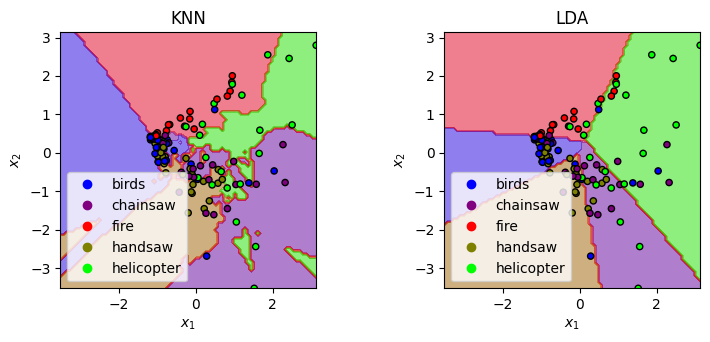

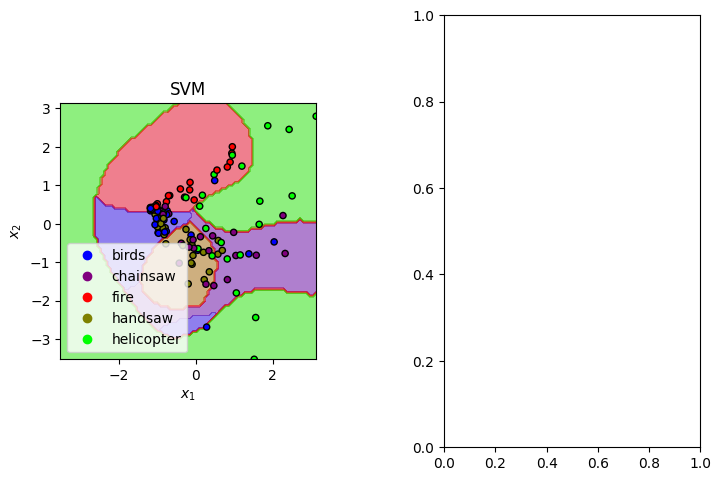

In [438]:
### TO RUN
n = 2  # Number of principal components kept
pca = PCA(n_components=n, whiten=True)
X_learn_reduced = pca.fit_transform(X_train[idx_learn])
X_val_reduced = pca.transform(X_train[idx_val])

print(f"Shape of the reduced training matrix : {X_learn_reduced.shape}")

y_train_num = np.zeros(y_train.shape)
for i, classname in enumerate(classnames):
    y_train_num[y_train == classname] = i

K = 10
model_knn = KNeighborsClassifier(n_neighbors=K)
model_knn.fit(X_learn_reduced, y_train_num[idx_learn])
prediction_knn = model_knn.predict(X_val_reduced)
accuracy_knn = accuracy(prediction_knn, y_train_num[idx_val])

model_lda = LDA()
model_lda.fit(X_learn_reduced, y_train_num[idx_learn])
prediction_lda = model_lda.predict(X_val_reduced)
accuracy_lda = accuracy(prediction_lda, y_train_num[idx_val])

model_svm = SVC()
model_svm.fit(X_learn_reduced, y_train_num[idx_learn])
prediction_svm = model_svm.predict(X_val_reduced)
accuracy_svm = accuracy(prediction_svm, y_train_num[idx_val])

fig = plt.figure()
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]
plot_decision_boundaries(
    X_learn_reduced,
    y_train_num[idx_learn],
    ax=axs[0],
    model=model_knn,
    legend=classnames,
    title="KNN",
)
plot_decision_boundaries(
    X_learn_reduced,
    y_train_num[idx_learn],
    ax=axs[1],
    model=model_lda,
    legend=classnames,
    title="LDA",
)


plt.show()

fig = plt.figure()
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]
plot_decision_boundaries(
    X_learn_reduced,
    y_train_num[idx_learn],
    ax=axs[0],
    model=model_svm,
    legend=classnames,
    title="SVM",
)
plt.show()


**Question**: 
- From the decision boundaries shown here above, can you explain why the ``handsaw`` class is less often chosen than the other classes for the ``KNN`` classifier?

TO COMPLETE

Answer the questions above


There seems to be an overfitting on the handsaw label, it is thus less chosen as overfitting reacts wrongly when we provide the algorithm with unseen data.



Shape of the reduced learning matrix : (112, 5)
Accuracy of the KNN : 60.7%


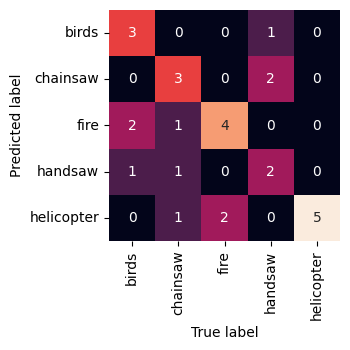

Accuracy of the LDA : 42.9%


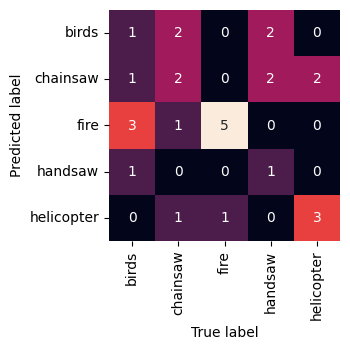

Accuracy of the SVM : 39.3%


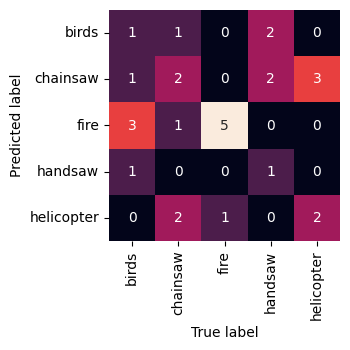

In [439]:
### TO RUN
n = 5  # Number of principal components kept
pca = PCA(n_components=n, whiten=True)
X_learn_reduced = pca.fit_transform(X_train[idx_learn])
X_val_reduced = pca.transform(X_train[idx_val])

print(f"Shape of the reduced learning matrix : {X_learn_reduced.shape}")

K = 10
model_knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
model_knn.fit(X_learn_reduced, y_train[idx_learn])
prediction_knn = model_knn.predict(X_val_reduced)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])

model_lda = LDA()
model_lda.fit(X_learn_reduced, y_train[idx_learn])
prediction_lda = model_lda.predict(X_val_reduced)
accuracy_lda = accuracy(prediction_lda, y_train[idx_val])

model_svm = SVC()
model_svm.fit(X_learn_reduced, y_train[idx_learn])
prediction_svm = model_svm.predict(X_val_reduced)
accuracy_svm = accuracy(prediction_svm, y_train[idx_val])

print(f"Accuracy of the KNN : {100 * accuracy_knn:.1f}%")
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
print(f"Accuracy of the LDA : {100 * accuracy_lda:.1f}%")
show_confusion_matrix(prediction_lda, y_train[idx_val], classnames)
print(f"Accuracy of the SVM : {100 * accuracy_svm:.1f}%")
show_confusion_matrix(prediction_svm, y_train[idx_val], classnames)

<font size=5 color=#009999> 2.5. Analysis of the hyperparameters </font> <br>

Finally, we can inspect the influence of ``hyperparameters`` as we did for the toy example. <br>
Let us start by analyzing the influence of the number of neighbours $K$ in the KNN. 

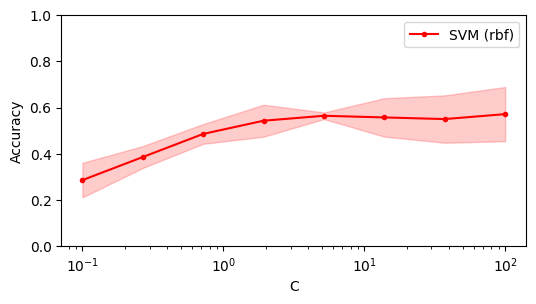

Best C: 100.0 (mean accuracy 0.571)


<Figure size 600x600 with 0 Axes>

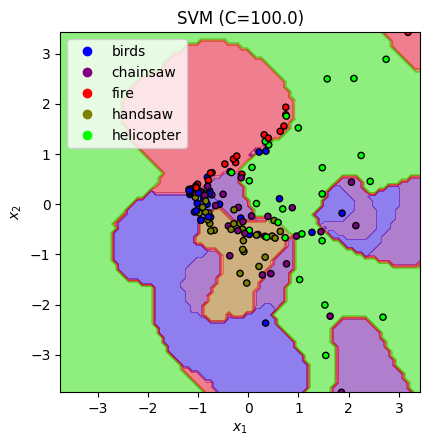

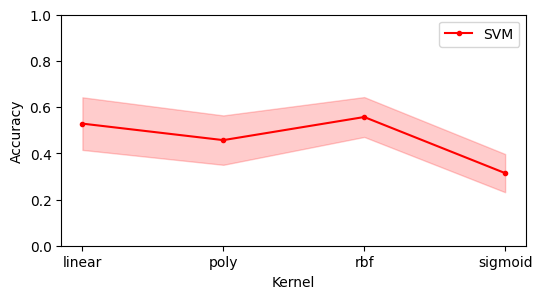

In [440]:
### TO RUN
# Ks = np.arange(6, 15, 1)
# accuracies_knn = np.zeros((len(Ks), n_splits))
# for i, K in enumerate(Ks):
#     model_knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
#     for k, idx in enumerate(kf.split(X_train, y_train)):
#         (idx_learn, idx_val) = idx
#         model_knn.fit(X_train[idx_learn], y_train[idx_learn])
#         prediction_knn = model_knn.predict(X_train[idx_val])
#         accuracies_knn[i, k] = accuracy(prediction_knn, y_train[idx_val])
# means_knn = accuracies_knn.mean(axis=1)
# stds_knn = accuracies_knn.std(axis=1)

# "Plot"
# plt.figure(figsize=(6, 3))
# plt.plot(Ks, means_knn, ".-b", label="KNN")
# plt.fill_between(Ks, means_knn - stds_knn, means_knn + stds_knn, alpha=0.2, color="b")
# plt.ylim(0, 1)
# plt.xlabel("K")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

# modify SVC c parameters and rerun cross-validation only for svm 

# iterate over values of C 
Cs = np.logspace(-1, 2, 8)  # try C in [0.1 .. 100]
accuracy_svm = np.zeros((len(Cs), n_splits))

for i, C in enumerate(Cs):
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        model_tmp = SVC(C=C, kernel="rbf", gamma="scale", random_state=0)
        model_tmp.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_tmp = model_tmp.predict(X_train[idx_val])
        accuracy_svm[i, k] = accuracy(prediction_tmp, y_train[idx_val])

means_svm = accuracy_svm.mean(axis=1)
stds_svm = accuracy_svm.std(axis=1)

# plot results
plt.figure(figsize=(6, 3))
plt.semilogx(Cs, means_svm, ".-r", label="SVM (rbf)")
plt.fill_between(Cs, means_svm - stds_svm, means_svm + stds_svm, alpha=0.2, color="r")
plt.ylim(0, 1)
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# pick best C and set model_svm for the following CV
best_idx = np.argmax(means_svm)
best_C = Cs[best_idx]
print(f"Best C: {best_C} (mean accuracy {means_svm[best_idx]:.3f})")
model_svm = SVC(C=best_C, kernel="rbf", gamma="scale", random_state=0)



n = 2  # Number of PCA components
pca = PCA(n_components=n, whiten=True)
X_train_reduced = pca.fit_transform(X_train)

# Convert class labels to integers for SVM
y_train_num = np.zeros(y_train.shape, dtype=int)
for i, classname in enumerate(classnames):
    y_train_num[y_train == classname] = i

# Fit SVM on reduced data using numeric labels
model_svm.fit(X_train_reduced, y_train_num)

# Plot decision boundaries using numeric labels
plt.figure(figsize=(6, 6))
plot_decision_boundaries(
    X_train_reduced,
    y_train_num,
    model=model_svm,
    legend=classnames,
    title=f"SVM (C={best_C})"
)
plt.show()

# modify SVC Kernel parameters
kernels = ["linear", "poly", "rbf", "sigmoid"]
accuracy_svm = np.zeros((len(kernels), n_splits))
for i, kernel in enumerate(kernels):
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        model_tmp = SVC(C=best_C, kernel=kernel, gamma="scale", random_state=0)
        model_tmp.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_tmp = model_tmp.predict(X_train[idx_val])
        accuracy_svm[i, k] = accuracy(prediction_tmp, y_train[idx_val])

means_svm = accuracy_svm.mean(axis=1)
stds_svm = accuracy_svm.std(axis=1)

# plot results
plt.figure(figsize=(6, 3))
plt.plot(kernels, means_svm, ".-r", label="SVM")
plt.fill_between(kernels, means_svm - stds_svm, means_svm + stds_svm, alpha=0.2, color="r")
plt.ylim(0, 1)
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


🔄 Testing C values: [  0.1          0.11513954   0.13257114   0.1526418    0.17575106
   0.20235896   0.23299518   0.26826958   0.30888436   0.35564803
   0.40949151   0.47148664   0.54286754   0.62505519   0.71968567
   0.82864277   0.95409548   1.09854114   1.26485522   1.45634848
   1.67683294   1.93069773   2.22299648   2.55954792   2.9470517
   3.39322177   3.90693994   4.49843267   5.17947468   5.96362332
   6.86648845   7.90604321   9.10298178  10.48113134  12.06792641
  13.89495494  15.9985872   18.42069969  21.20950888  24.42053095
  28.11768698  32.37457543  37.2759372   42.9193426   49.41713361
  56.89866029  65.51285569  75.43120063  86.85113738 100.        ]


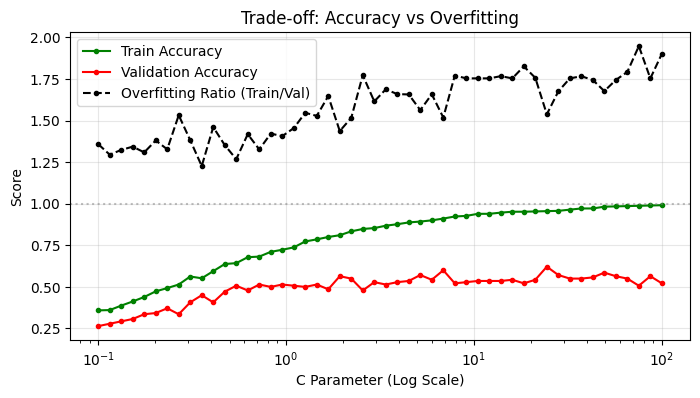

------------------------------
🏆 Best C selected: 24.420530945486497
   Train Acc : 0.955
   Val Acc   : 0.621
   Ratio     : 1.537 (Lower is better, ideal is 1.0)
------------------------------


<Figure size 600x600 with 0 Axes>

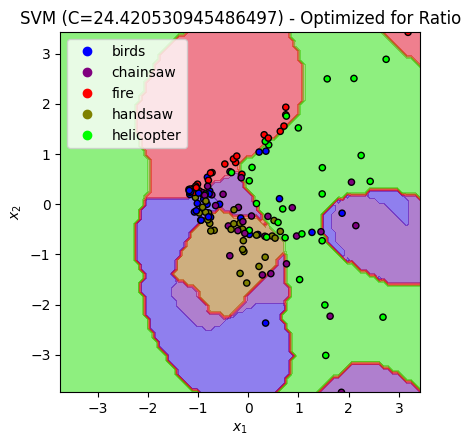

🏆 Best Kernel: rbf (Ratio: 1.807)


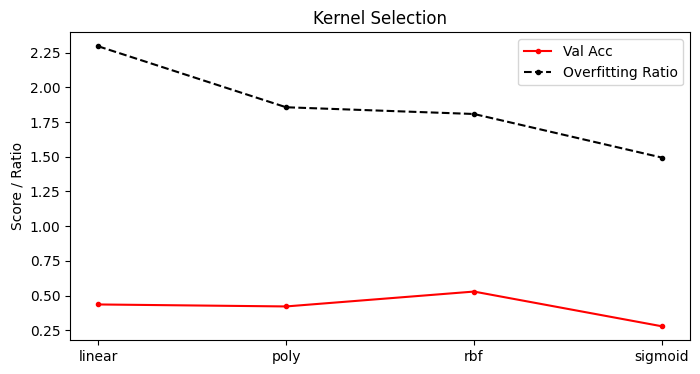

In [441]:
# -------------------------------------------------------------------------
# 1. OPTIMIZE C (With Overfitting Check)
# -------------------------------------------------------------------------

Cs = np.logspace(-1, 2, 50)  # Try C in [0.1 .. 100]

# We now need to store TWO values per split
train_acc_store = np.zeros((len(Cs), n_splits))
val_acc_store   = np.zeros((len(Cs), n_splits))

print(f"🔄 Testing C values: {Cs}")

for i, C in enumerate(Cs):
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        
        # Initialize and Fit
        model_tmp = SVC(C=C, kernel="rbf", gamma="scale", random_state=0)
        model_tmp.fit(X_train[idx_learn], y_train[idx_learn])
        
        # 1. Validation Accuracy (Standard)
        pred_val = model_tmp.predict(X_train[idx_val])
        val_acc_store[i, k] = accuracy(pred_val, y_train[idx_val])
        
        # 2. Training Accuracy (To check Overfitting)
        pred_train = model_tmp.predict(X_train[idx_learn])
        train_acc_store[i, k] = accuracy(pred_train, y_train[idx_learn])

# Average across folds
means_train = train_acc_store.mean(axis=1)
means_val   = val_acc_store.mean(axis=1)

# --- CALCULATE THE RATIO ---
# Ratio = 1.0 means perfect generalization (Train == Val)
# Ratio = 1.2 means 20% Overfitting (Train is 20% higher than Val)
overfitting_ratios = means_train / means_val

# --- PLOT BOTH CURVES ---
plt.figure(figsize=(8, 4))
plt.semilogx(Cs, means_train, ".-g", label="Train Accuracy")
plt.semilogx(Cs, means_val,   ".-r", label="Validation Accuracy")
plt.semilogx(Cs, overfitting_ratios, ".--k", label="Overfitting Ratio (Train/Val)")

# Add a line at 1.0 (Ideal Ratio)
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

plt.xlabel("C Parameter (Log Scale)")
plt.ylabel("Score")
plt.title("Trade-off: Accuracy vs Overfitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- INTELLIGENT SELECTION LOGIC ---
# Strategy: We want High Validation Accuracy, but we penalize High Ratios.
# Formula: Generalization_Score = Val_Acc / Ratio
# This balances "being right" with "being honest"

generalization_scores = means_val / overfitting_ratios
best_idx = np.argmax(generalization_scores)
best_C = Cs[best_idx]

print("-" * 30)
print(f"🏆 Best C selected: {best_C}")
print(f"   Train Acc : {means_train[best_idx]:.3f}")
print(f"   Val Acc   : {means_val[best_idx]:.3f}")
print(f"   Ratio     : {overfitting_ratios[best_idx]:.3f} (Lower is better, ideal is 1.0)")
print("-" * 30)

model_svm = SVC(C=best_C, kernel="rbf", gamma="scale", random_state=0)

# -------------------------------------------------------------------------
# 2. VISUALIZATION (PCA) - Unchanged
# -------------------------------------------------------------------------
n = 2 
pca = PCA(n_components=n, whiten=True)
X_train_reduced = pca.fit_transform(X_train)

y_train_num = np.zeros(y_train.shape, dtype=int)
for i, classname in enumerate(classnames):
    y_train_num[y_train == classname] = i

model_svm.fit(X_train_reduced, y_train_num)

plt.figure(figsize=(6, 6))
plot_decision_boundaries(
    X_train_reduced, y_train_num, model=model_svm, legend=classnames,
    title=f"SVM (C={best_C}) - Optimized for Ratio"
)
plt.show()

# -------------------------------------------------------------------------
# 3. KERNEL SELECTION (With Same Logic)
# -------------------------------------------------------------------------
kernels = ["linear", "poly", "rbf", "sigmoid"]

k_train_acc = np.zeros((len(kernels), n_splits))
k_val_acc   = np.zeros((len(kernels), n_splits))

for i, kernel in enumerate(kernels):
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        model_tmp = SVC(C=best_C, kernel=kernel, gamma="scale", random_state=0)
        model_tmp.fit(X_train[idx_learn], y_train[idx_learn])
        
        # Store both scores
        k_val_acc[i, k]   = accuracy(model_tmp.predict(X_train[idx_val]), y_train[idx_val])
        k_train_acc[i, k] = accuracy(model_tmp.predict(X_train[idx_learn]), y_train[idx_learn])

k_means_train = k_train_acc.mean(axis=1)
k_means_val   = k_val_acc.mean(axis=1)
k_ratios      = k_means_train / k_means_val

# Selection based on same metric
k_scores = k_means_val / k_ratios
best_k_idx = np.argmax(k_scores)

print(f"🏆 Best Kernel: {kernels[best_k_idx]} (Ratio: {k_ratios[best_k_idx]:.3f})")

plt.figure(figsize=(8, 4))
plt.plot(kernels, k_means_val, ".-r", label="Val Acc")
plt.plot(kernels, k_ratios, ".--k", label="Overfitting Ratio")
plt.ylabel("Score / Ratio")
plt.title("Kernel Selection")
plt.legend()
plt.show()

🔄 Generating Data (Separating Original vs Augmented)...
✔ Data Ready: Originals=(128, 400), Augmented=(384, 400)

🚀 STEP 1: Optimizing C...


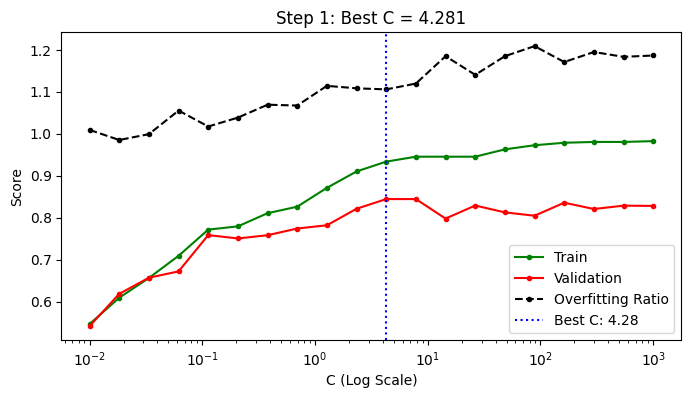

🏆 Best C selected: 4.2813

🚀 STEP 2: Optimizing Gamma...


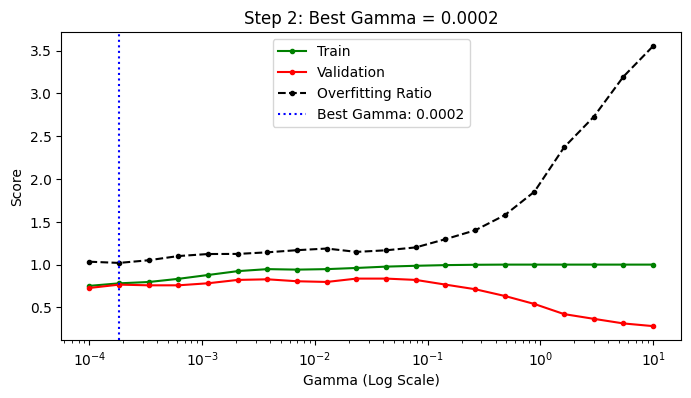

🏆 Best Gamma selected: 0.0002

🚀 STEP 3: Optimizing Kernel...


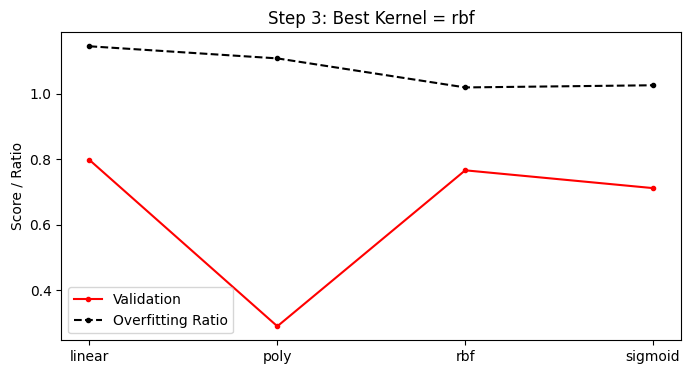

🏆 Best Kernel selected: rbf

🎨 Generating Decision Boundary Plot (PCA 2D)...


<Figure size 600x600 with 0 Axes>

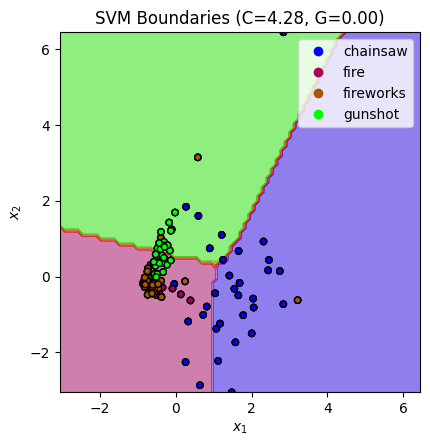


🏋️‍♂️ Final Training & Test...
----------------------------------------
🎯 Final Test Accuracy: 0.7812
📈 Final Train Accuracy: 0.7656
----------------------------------------

📊 Confusion Matrix: TRAINING SET (Check fit)


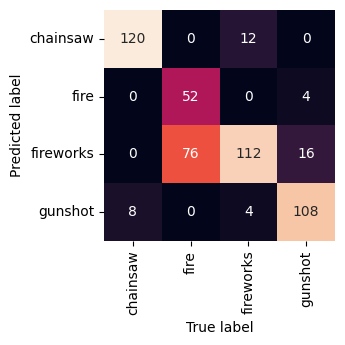


📊 Confusion Matrix: TEST SET (Check generalization)


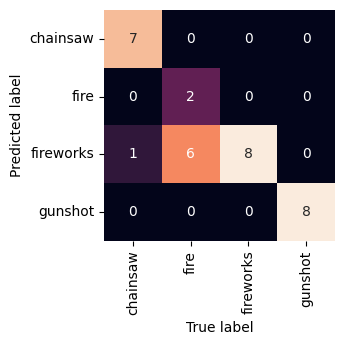

In [ ]:
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

# Custom imports from your project structure
from src.classification.datasets import Dataset
from src.classification.utils.audio_student import AudioUtil, Feature_vector_DS
from src.classification.utils.plots import plot_decision_boundaries, show_confusion_matrix

# -------------------------------------------------------
# PART 0: SETUP & DATA GENERATION (STRICT SEPARATION)
# -------------------------------------------------------
dataset = Dataset()
# Filter classes
dataset.remove_class("background")
dataset.remove_class("handsaw")
dataset.remove_class("birds")
dataset.remove_class("helicopter")
classnames = dataset.list_classes()

# Initialize Feature Extractor
myds = Feature_vector_DS(dataset, Nft=512, nmel=20, duration=950, step=np.inf)
TARGET_SHAPE = (20, 20)

def get_fixed_feature(dataset, classname, idx):
    feat2d = dataset[classname, idx]
    if feat2d.shape != TARGET_SHAPE:
        feat2d = resize(feat2d, TARGET_SHAPE, mode='reflect', anti_aliasing=True)
    return feat2d.reshape(-1)

# Augmentation Config
aug_list_extras = ["time_shift", "add_echo"]
aug_list_base   = ["original"]

# Storage containers
X_train_orig, y_train_orig = [], []   
X_train_aug, y_train_aug   = [], []   
aug_map = []                          
X_test, y_test = [], []

print("🔄 Generating Data (Separating Original vs Augmented)...")

for classname in classnames:
    n_audio = dataset.naudio[classname]
    indices = np.arange(n_audio)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    # 1. Training Originals
    myds.mod_data_aug(aug_list_base)
    class_start_index = len(X_train_orig)
    for idx in train_idx:
        feat = get_fixed_feature(myds, classname, idx)
        X_train_orig.append(feat)
        y_train_orig.append(classname)
        
    # 2. Training Augmentations (Mapped)
    myds.mod_data_aug(aug_list_extras)
    for s in range(myds.data_aug_factor):
        for i, idx in enumerate(train_idx):
            feat = get_fixed_feature(myds, classname, idx)
            X_train_aug.append(feat)
            y_train_aug.append(classname)
            # Map this augmented sample back to the index of its parent in X_train_orig
            aug_map.append(class_start_index + i)

    # 3. Test Set (Pure)
    myds.mod_data_aug(aug_list_base)
    for idx in test_idx:
        feat = get_fixed_feature(myds, classname, idx)
        X_test.append(feat)
        y_test.append(classname)

# Convert to Numpy
X_train_orig = np.array(X_train_orig)
y_train_orig = np.array(y_train_orig)
X_train_aug  = np.array(X_train_aug)
y_train_aug  = np.array(y_train_aug)
aug_map      = np.array(aug_map)
X_test       = np.array(X_test)
y_test       = np.array(y_test)

print(f"✔ Data Ready: Originals={X_train_orig.shape}, Augmented={X_train_aug.shape}")

# -------------------------------------------------------
# HELPER: STRICT K-FOLD LOOP
# -------------------------------------------------------
def accuracy(preds, true):
    return accuracy_score(true, preds)

def run_strict_kfold(param_name, param_values, best_C=None, best_gamma=None):
    """
    Runs K-Fold where validation is ONLY on originals.
    """
    n_splits = 5
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    train_scores = np.zeros((len(param_values), n_splits))
    val_scores   = np.zeros((len(param_values), n_splits))
    
    for i, val in enumerate(param_values):
        for k, (idx_learn, idx_val) in enumerate(kf.split(X_train_orig, y_train_orig)):
            
            # 1. Build Folds
            X_fold_val = X_train_orig[idx_val]
            y_fold_val = y_train_orig[idx_val]
            
            X_learn_orig = X_train_orig[idx_learn]
            y_learn_orig = y_train_orig[idx_learn]
            
            # Find matching augmented data for the training fold
            mask_aug = np.isin(aug_map, idx_learn)
            X_learn_aug = X_train_aug[mask_aug]
            y_learn_aug = y_train_aug[mask_aug]
            
            # Mix Original + Aug for Training
            X_fold_train = np.concatenate([X_learn_orig, X_learn_aug])
            y_fold_train = np.concatenate([y_learn_orig, y_learn_aug])
            X_fold_train, y_fold_train = shuffle(X_fold_train, y_fold_train, random_state=0)
            
            # 2. Pre-processing (Inside loop to prevent leakage)
            scaler = StandardScaler()
            X_fold_train_sc = scaler.fit_transform(X_fold_train)
            X_fold_val_sc   = scaler.transform(X_fold_val)
            
            pca = PCA(n_components=0.8, random_state=1)
            X_fold_train_pca = pca.fit_transform(X_fold_train_sc)
            X_fold_val_pca   = pca.transform(X_fold_val_sc)
            
            # 3. Model Configuration
            if param_name == 'C':
                model = SVC(C=val, kernel="rbf", gamma="scale", random_state=0)
            elif param_name == 'gamma':
                model = SVC(C=best_C, kernel="rbf", gamma=val, random_state=0)
            elif param_name == 'kernel':
                g = best_gamma if val in ['rbf', 'poly', 'sigmoid'] else 'scale'
                model = SVC(C=best_C, kernel=val, gamma=g, random_state=0)
                
            model.fit(X_fold_train_pca, y_fold_train)
            
            val_scores[i, k]   = accuracy(model.predict(X_fold_val_pca), y_fold_val)
            train_scores[i, k] = accuracy(model.predict(X_fold_train_pca), y_fold_train)
            
    return train_scores, val_scores

# -------------------------------------------------------
# PART 1: OPTIMIZE C (Regularization)
# -------------------------------------------------------
print(f"\n🚀 STEP 1: Optimizing C...")
Cs = np.logspace(-2, 3, 20) 
train_acc, val_acc = run_strict_kfold('C', Cs)

means_train = train_acc.mean(axis=1)
means_val   = np.maximum(val_acc.mean(axis=1), 1e-10)
ratios = means_train / means_val
scores = means_val / ratios
best_idx = np.argmax(scores)
best_C = Cs[best_idx]

# Plot C
plt.figure(figsize=(8, 4))
plt.semilogx(Cs, means_train, ".-g", label="Train")
plt.semilogx(Cs, means_val,   ".-r", label="Validation")
plt.semilogx(Cs, ratios, ".--k", label="Overfitting Ratio")
plt.axvline(x=best_C, color='blue', linestyle=':', label=f"Best C: {best_C:.2f}")
plt.xlabel("C (Log Scale)")
plt.ylabel("Score")
plt.title(f"Step 1: Best C = {best_C:.3f}")
plt.legend()
plt.show()

print(f"🏆 Best C selected: {best_C:.4f}")

# -------------------------------------------------------
# PART 2: OPTIMIZE GAMMA (Curve Shape)
# -------------------------------------------------------
print(f"\n🚀 STEP 2: Optimizing Gamma...")
Gammas = np.logspace(-4, 1, 20)
train_acc_g, val_acc_g = run_strict_kfold('gamma', Gammas, best_C=best_C)

means_train_g = train_acc_g.mean(axis=1)
means_val_g   = np.maximum(val_acc_g.mean(axis=1), 1e-10)
ratios_g = means_train_g / means_val_g
scores_g = means_val_g / ratios_g
best_idx_g = np.argmax(scores_g)
best_gamma = Gammas[best_idx_g]

# Plot Gamma
plt.figure(figsize=(8, 4))
plt.semilogx(Gammas, means_train_g, ".-g", label="Train")
plt.semilogx(Gammas, means_val_g,   ".-r", label="Validation")
plt.semilogx(Gammas, ratios_g, ".--k", label="Overfitting Ratio")
plt.axvline(x=best_gamma, color='blue', linestyle=':', label=f"Best Gamma: {best_gamma:.4f}")
plt.xlabel("Gamma (Log Scale)")
plt.ylabel("Score")
plt.title(f"Step 2: Best Gamma = {best_gamma:.4f}")
plt.legend()
plt.show()

print(f"🏆 Best Gamma selected: {best_gamma:.4f}")

# -------------------------------------------------------
# PART 3: OPTIMIZE KERNEL
# -------------------------------------------------------
print(f"\n🚀 STEP 3: Optimizing Kernel...")
kernels = ["linear", "poly", "rbf", "sigmoid"]
train_acc_k, val_acc_k = run_strict_kfold('kernel', kernels, best_C=best_C, best_gamma=best_gamma)

means_train_k = train_acc_k.mean(axis=1)
means_val_k   = np.maximum(val_acc_k.mean(axis=1), 1e-10)
ratios_k = means_train_k / means_val_k
scores_k = means_val_k / ratios_k
best_idx_k = np.argmax(scores_k)
best_kernel = kernels[best_idx_k]

# Plot Kernel
plt.figure(figsize=(8, 4))
plt.plot(kernels, means_val_k, ".-r", label="Validation")
plt.plot(kernels, ratios_k, ".--k", label="Overfitting Ratio")
plt.ylabel("Score / Ratio")
plt.title(f"Step 3: Best Kernel = {best_kernel}")
plt.legend()
plt.show()

print(f"🏆 Best Kernel selected: {best_kernel}")


Here is the updated master script. I have added Step 1: PCA Variance Optimization.

This is a crucial addition because the number of dimensions you keep (e.g., 80% vs 99% of variance) drastically changes what the SVM "sees."

📋 The New Optimization Pipeline
Optimize PCA Variance (How much information to keep? 0.75? 0.90?)

Optimize C (Regularization strength)

Optimize Gamma (RBF curve shape)

Optimize Kernel (Math function)

📜 Complete Master Script (PCA + SVM Optimization)
Python
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

# Custom imports
from src.classification.datasets import Dataset
from src.classification.utils.audio_student import AudioUtil, Feature_vector_DS
from src.classification.utils.plots import plot_decision_boundaries, show_confusion_matrix

# -------------------------------------------------------
# PART 0: SETUP & DATA GENERATION (STRICT SEPARATION)
# -------------------------------------------------------
dataset = Dataset()
dataset.remove_class("background")
dataset.remove_class("fireworks")
dataset.remove_class("gunshot")
classnames = dataset.list_classes()

myds = Feature_vector_DS(dataset, Nft=512, nmel=20, duration=950, step=np.inf)
TARGET_SHAPE = (20, 20)

def get_fixed_feature(dataset, classname, idx):
    feat2d = dataset[classname, idx]
    if feat2d.shape != TARGET_SHAPE:
        feat2d = resize(feat2d, TARGET_SHAPE, mode='reflect', anti_aliasing=True)
    return feat2d.reshape(-1)

# Augmentation Config
aug_list_extras = ["time_shift", "add_noise", "add_echo"]
aug_list_base   = ["original"]

X_train_orig, y_train_orig = [], []   
X_train_aug, y_train_aug   = [], []   
aug_map = []                          
X_test, y_test = [], []

print("🔄 Generating Data (Separating Original vs Augmented)...")

for classname in classnames:
    n_audio = dataset.naudio[classname]
    indices = np.arange(n_audio)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    # 1. Training Originals
    myds.mod_data_aug(aug_list_base)
    class_start_index = len(X_train_orig)
    for idx in train_idx:
        feat = get_fixed_feature(myds, classname, idx)
        X_train_orig.append(feat)
        y_train_orig.append(classname)
        
    # 2. Training Augmentations (Mapped)
    myds.mod_data_aug(aug_list_extras)
    for s in range(myds.data_aug_factor):
        for i, idx in enumerate(train_idx):
            feat = get_fixed_feature(myds, classname, idx)
            X_train_aug.append(feat)
            y_train_aug.append(classname)
            aug_map.append(class_start_index + i)

    # 3. Test Set
    myds.mod_data_aug(aug_list_base)
    for idx in test_idx:
        feat = get_fixed_feature(myds, classname, idx)
        X_test.append(feat)
        y_test.append(classname)

X_train_orig = np.array(X_train_orig)
y_train_orig = np.array(y_train_orig)
X_train_aug  = np.array(X_train_aug)
y_train_aug  = np.array(y_train_aug)
aug_map      = np.array(aug_map)
X_test       = np.array(X_test)
y_test       = np.array(y_test)

print(f"✔ Data Ready: Originals={X_train_orig.shape}, Augmented={X_train_aug.shape}")

# -------------------------------------------------------
# HELPER: STRICT K-FOLD LOOP (Now Handles PCA Optimization)
# -------------------------------------------------------


def accuracy(preds, true):
    return accuracy_score(true, preds)

def run_strict_kfold(param_name, param_values, best_pca_var=0.8, best_C=1.0, best_gamma='scale'):
    """
    Runs K-Fold where validation is ONLY on originals.
    Can optimize PCA, C, Gamma, or Kernel.
    """
    n_splits = 5
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    train_scores = np.zeros((len(param_values), n_splits))
    val_scores   = np.zeros((len(param_values), n_splits))
    
    for i, val in enumerate(param_values):
        for k, (idx_learn, idx_val) in enumerate(kf.split(X_train_orig, y_train_orig)):
            
            # --- 1. BUILD FOLDS ---
            # Validation Fold (PURE ORIGINALS)
            X_fold_val = X_train_orig[idx_val]
            y_fold_val = y_train_orig[idx_val]
            
            # Training Fold (MIXED)
            X_learn_orig = X_train_orig[idx_learn]
            y_learn_orig = y_train_orig[idx_learn]
            
            # Find matching augmented samples
            mask_aug = np.isin(aug_map, idx_learn)
            X_learn_aug = X_train_aug[mask_aug]
            y_learn_aug = y_train_aug[mask_aug]
            
            X_fold_train = np.concatenate([X_learn_orig, X_learn_aug])
            y_fold_train = np.concatenate([y_learn_orig, y_learn_aug])
            X_fold_train, y_fold_train = shuffle(X_fold_train, y_fold_train, random_state=0)
            
            # --- 2. PRE-PROCESSING (PCA varies here if param_name == 'pca') ---
            scaler = StandardScaler()
            X_fold_train_sc = scaler.fit_transform(X_fold_train)
            X_fold_val_sc   = scaler.transform(X_fold_val)
            
            # DETERMINE CURRENT PCA VARIANCE
            current_pca = val if param_name == 'pca' else best_pca_var
            
            pca = PCA(n_components=current_pca, random_state=1)
            X_fold_train_pca = pca.fit_transform(X_fold_train_sc)
            X_fold_val_pca   = pca.transform(X_fold_val_sc)
            
            # --- 3. MODEL CONFIGURATION ---
            # Default params if we are optimizing PCA
            if param_name == 'pca':
                model = SVC(C=1.0, kernel="rbf", gamma="scale", random_state=0)
            elif param_name == 'C':
                model = SVC(C=val, kernel="rbf", gamma="scale", random_state=0)
            elif param_name == 'gamma':
                model = SVC(C=best_C, kernel="rbf", gamma=val, random_state=0)
            elif param_name == 'kernel':
                g = best_gamma if val in ['rbf', 'poly', 'sigmoid'] else 'scale'
                model = SVC(C=best_C, kernel=val, gamma=g, random_state=0)
                
            model.fit(X_fold_train_pca, y_fold_train)
            
            val_scores[i, k]   = accuracy(model.predict(X_fold_val_pca), y_fold_val)
            train_scores[i, k] = accuracy(model.predict(X_fold_train_pca), y_fold_train)
            
    return train_scores, val_scores

# -------------------------------------------------------
# PART 1: OPTIMIZE PCA VARIANCE (New Step!)
# -------------------------------------------------------
# We test keeping 60% to 99% of the variance
print(f"\n🚀 STEP 1: Optimizing PCA Variance...")
pca_vars = [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99]

train_acc, val_acc = run_strict_kfold('pca', pca_vars)

means_train = train_acc.mean(axis=1)
means_val   = np.maximum(val_acc.mean(axis=1), 1e-10)
ratios = means_train / means_val
scores = means_val / ratios
best_idx = np.argmax(scores)
best_pca_var = pca_vars[best_idx]

# Plot PCA
plt.figure(figsize=(8, 4))
plt.plot(pca_vars, means_train, "o-g", label="Train")
plt.plot(pca_vars, means_val,   "o-r", label="Validation")
plt.plot(pca_vars, ratios, "x--k", label="Overfitting Ratio")
plt.axvline(x=best_pca_var, color='blue', linestyle=':', label=f"Best Var: {best_pca_var}")
plt.xlabel("PCA Explained Variance (0.0 - 1.0)")
plt.ylabel("Score")
plt.title(f"Step 1: Best PCA Variance = {best_pca_var}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"🏆 Best PCA Variance: {best_pca_var}")
# -------------------------------------------------------
# PART 4: VISUALIZATION (Decision Boundaries)
# -------------------------------------------------------
print("\n🎨 Generating Decision Boundary Plot (PCA 2D)...")
X_total_train = np.concatenate([X_train_orig, X_train_aug])
y_total_train = np.concatenate([y_train_orig, y_train_aug])

# Scaler + PCA to 2D
scaler_vis = StandardScaler()
X_vis_norm = scaler_vis.fit_transform(X_total_train)
pca_vis = PCA(n_components=2, whiten=True)
X_vis_2d = pca_vis.fit_transform(X_vis_norm)

# Convert labels to int
y_vis_num = np.zeros(y_total_train.shape, dtype=int)
for i, classname in enumerate(classnames):
    y_vis_num[y_total_train == classname] = i

model_vis = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma, random_state=0)
model_vis.fit(X_vis_2d, y_vis_num)

plt.figure(figsize=(6, 6))
plot_decision_boundaries(
    X_vis_2d, y_vis_num, model=model_vis, legend=classnames,
    title=f"SVM Boundaries (C={best_C:.2f}, G={best_gamma:.2f})"
)
plt.show()


# -------------------------------------------------------
# PART 5: FINAL EVALUATION & MATRICES
# -------------------------------------------------------
print("\n🏋️‍♂️ Final Training & Test...")

# 1. Combine ALL Data
X_final_train = np.concatenate([X_train_orig, X_train_aug])
y_final_train = np.concatenate([y_train_orig, y_train_aug])
X_final_train, y_final_train = shuffle(X_final_train, y_final_train, random_state=0)

# 2. Final Pipeline
scaler_final = StandardScaler()
X_train_final_sc = scaler_final.fit_transform(X_final_train)
X_test_final_sc  = scaler_final.transform(X_test)

pca_final = PCA(n_components=0.8, random_state=1)
X_train_final_pca = pca_final.fit_transform(X_train_final_sc)
X_test_final_pca  = pca_final.transform(X_test_final_sc)

# 3. Train Final Model
final_model = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma, probability=True, random_state=0)
final_model.fit(X_train_final_pca, y_final_train)

# 4. Predictions
y_pred_train = final_model.predict(X_train_final_pca)
y_pred_test  = final_model.predict(X_test_final_pca)

# 5. Final Report
print("-" * 40)
print(f"🎯 Final Test Accuracy: {accuracy(y_pred_test, y_test):.4f}")
print(f"📈 Final Train Accuracy: {accuracy(y_pred_train, y_final_train):.4f}")
print("-" * 40)

# 6. Confusion Matrices
print("\n📊 Confusion Matrix: TRAINING SET (Check fit)")
show_confusion_matrix(y_pred_train, y_final_train, classnames)

print("\n📊 Confusion Matrix: TEST SET (Check generalization)")
show_confusion_matrix(y_pred_test, y_test, classnames)

Here we consider both ``K`` and the number of principal components ``n``.

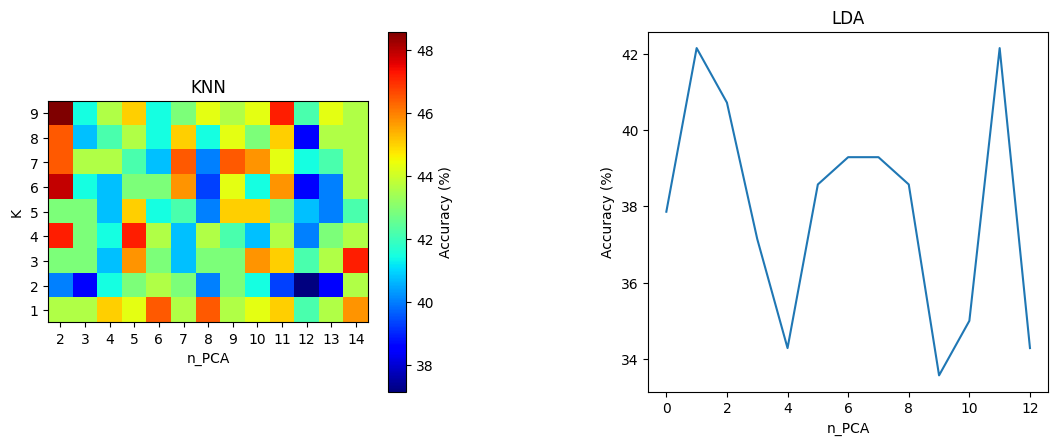

In [443]:
### TO RUN
Ks = np.arange(1, 10)
n_comps = np.arange(2, 15)  # number of principal components kept for the PCA
accuracies_knn = np.zeros((len(Ks), len(n_comps)))
accuracies_lda = np.zeros(len(n_comps))

for j, n in enumerate(n_comps):
    for idx_learn, idx_val in kf.split(X_train, y_train):
        pca = PCA(n_components=n, whiten=True)
        X_learn_reduced = pca.fit_transform(X_train[idx_learn])
        X_val_reduced = pca.transform(X_train[idx_val])
        for i, K in enumerate(Ks):
            model_knn = KNeighborsClassifier(n_neighbors=K)
            model_knn.fit(X_train[idx_learn], y_train[idx_learn])
            prediction_knn = model_knn.predict(X_train[idx_val])
            accuracies_knn[i, j] += accuracy(prediction_knn, y_train[idx_val])

        model_lda = LDA()
        model_lda.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_lda = model_lda.predict(X_train[idx_val])
        accuracies_lda[j] += accuracy(prediction_lda, y_train[idx_val])

accuracies_knn /= n_splits
accuracies_lda /= n_splits

fig = plt.figure(figsize=(10, 4))
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]

im0 = axs[0].imshow(100 * accuracies_knn, cmap="jet", origin="lower")
cbar = fig.colorbar(im0, ax=axs[0])
cbar.set_label("Accuracy (%)")
axs[0].set_xlabel("n_PCA")
axs[0].set_ylabel("K")
axs[0].set_xticks(list(np.arange(len(n_comps))))
axs[0].set_xticklabels(list(n_comps))
axs[0].set_yticks(list(np.arange(len(Ks))))
axs[0].set_yticklabels(list(Ks))
axs[0].set_title("KNN")

axs[1].plot(accuracies_lda * 100)
axs[1].set_xlabel("n_PCA")
axs[1].set_ylabel("Accuracy (%)")
axs[1].set_title("LDA")
plt.show()

**Question**: 
- Do you observe some dependency of the accuracy on these parameters? If so, which one(s)? If not, discuss what it tells about the considered model. 

In [444]:
### TO COMPLETE
# Answer the question above

<font size=5 color=#009999> 2.6. Augmenting the data </font> <br>

In order to make our classifier more robust to some common transformations of the audio signal such as ``time shift``, ``AWGN``, or a ``transfer function``, an idea consists in feeding the classifier with such transformations. A popular approach is to create new feature vectors based on transformed versions of the sounds from the original dataset, this is called ``data augmentation``. Data augmentation is also often used when there is few data to train a model. <br>

The functions to augment your data are written in ``utils/audio_student.py``, we already implemented ``time_shift``, ``echo`` and ``spectro_aug_timefreq_masking`` for you. Try to implement ``scaling``, ``add_noise``, ``filter``, ``add_bg`` and even more data augmentation techniques if you want, and check their working in the cell below. <br>

<u>Tip</u>: to avoid restarting the notebook kernel for each modification, you can temporarily insert the ``AudioUtil`` class in a new cell and make your tests until it is working as expected. 

In [445]:
### TO RUN
myds.data_aug = None  # Ensure

cls_index = ["birds", 4]

sound = dataset.__getitem__(cls_index)
name = dataset.__getname__(cls_index)
audio = AudioUtil.open(sound)

AudioUtil.play(audio)
audio2 = AudioUtil.resample(audio, 11025)
audio2 = AudioUtil.pad_trunc(audio2, 5000)

audio3 = AudioUtil.scaling(audio2)
audio4 = AudioUtil.add_noise(audio2, sigma=1e-2)
audio5 = AudioUtil.echo(audio2, 3)
audio6 = AudioUtil.add_bg(audio2, dataset)

melspec = AudioUtil.melspectrogram(audio2, fs2=11025)
melspec2 = AudioUtil.spectro_aug_timefreq_masking(melspec, max_mask_pct=0.1)

"Plot"
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_axes([0.05, 0.05, 0.28, 0.9])
ax2 = fig.add_axes([0.38, 0.05, 0.28, 0.9])
ax3 = fig.add_axes([0.7, 0.05, 0.28, 0.9])

ax1.plot(audio2[0], label="Original")
ax1.plot(audio3[0] + 1, label="Rescaled")
ax1.plot(audio4[0] + 2, label="Noisy")
ax1.plot(audio5[0] + 3, label="With echos")
ax1.plot(audio6[0] + 4, label="With background sound")
ax1.legend()

plot_specgram(melspec, ax2, is_mel=True, title=name, tf=len(audio2[0]) / audio2[1])
ax2.set_title("Melspectrogram")
plot_specgram(melspec2, ax3, is_mel=True, title=name, tf=len(audio2[0]) / audio2[1])
ax3.set_title("Corrupted melspectrogram")
plt.show()

KeyError: 'birds'

We can now create a new augmented dataset and observe if the classification results improve. 

In [ ]:
# myds.mod_data_aug(["original","add_bg", "scaling", "time_shift", "add_noise", "add_echo"])
myds.mod_data_aug(["original","add_bg", "time_shift", "add_noise", "add_echo"])

# nombre de classes
nclass = len(classnames)

# nombre total d'audios (toutes classes confondues)
total_naudio = sum(dataset.naudio[c] for c in classnames)

# exemple de feature pour connaître la taille
example_feat = myds[classnames[0], 0]      # shape (20, 20)
featveclen = example_feat.size             # 20*20 = 400

print("Shape d'un feature (avant flatten) :", example_feat.shape)
print("Longueur du vecteur de features   :", featveclen)

# nombre total d'exemples augmentés
total_samples = myds.data_aug_factor * total_naudio

X_aug = np.zeros((total_samples, featveclen))
y_aug = np.empty((total_samples,), dtype=object)

k = 0  # index global dans X_aug / y_aug

for s in range(myds.data_aug_factor):
    for classname in classnames:
        n_audio_class = dataset.naudio[classname]
        for idx in range(n_audio_class):
            feat2d = myds[classname, idx]      # shape (20, 20)
            featvec = feat2d.reshape(-1)       # shape (400,)

            X_aug[k, :] = featvec
            y_aug[k] = classname
            k += 1

y_aug = np.array(y_aug)

print(f"Shape of the feature matrix : {X_aug.shape}")
print(f"Number of labels : {len(y_aug)}")
np.save(fm_dir + 'feature_matrix_2D_aug.npy', X_aug)
np.save(fm_dir + 'labels_aug.npy', y_aug)

Shape d'un feature (avant flatten) : (20, 20)
Longueur du vecteur de features   : 400
Shape of the feature matrix : (1200, 400)
Number of labels : 1200


Mean accuracy with 5-Fold CV: 76.2%
Std deviation in accuracy with 5-Fold CV: 3.2%


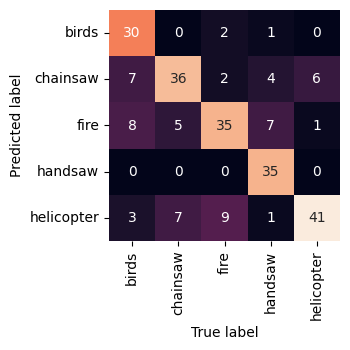

Mean accuracy with 5-Fold CV (SVM): 69.7%
Std deviation in accuracy with 5-Fold CV (SVM): 2.7%


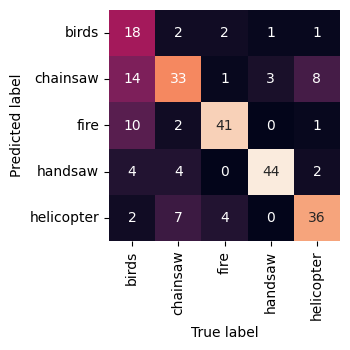

In [ ]:
### TO RUN
K = 10  # Number of neighbours
model = KNeighborsClassifier(n_neighbors=K)

accuracy_aug = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_aug, y_aug)):
    (idx_train, idx_test) = idx
    model.fit(X_aug[idx_train], y_aug[idx_train])
    prediction_aug = model.predict(X_aug[idx_test])
    accuracy_aug[k] = accuracy(prediction_aug, y_aug[idx_test])

print(f"Mean accuracy with 5-Fold CV: {100 * accuracy_aug.mean():.1f}%")
print(f"Std deviation in accuracy with 5-Fold CV: {100 * accuracy_aug.std():.1f}%")
show_confusion_matrix(prediction_aug, y_aug[idx_test], classnames)

model = SVC(C=best_C, kernel="rbf", gamma="scale", random_state=0)
accuracy_aug_svm = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_aug, y_aug)):
    (idx_train, idx_test) = idx
    model.fit(X_aug[idx_train], y_aug[idx_train])
    prediction_aug = model.predict(X_aug[idx_test])
    accuracy_aug_svm[k] = accuracy(prediction_aug, y_aug[idx_test])
print(f"Mean accuracy with 5-Fold CV (SVM): {100 * accuracy_aug_svm.mean():.1f}%")
print(f"Std deviation in accuracy with 5-Fold CV (SVM): {100 * accuracy_aug_svm.std():.1f}%")
show_confusion_matrix(prediction_aug, y_aug[idx_test], classnames)

**Questions**:
- Can you see an improvement of the classification result compared to the non augmented dataset? Try to interpret your answer by thinking about the distribution of points in a data space (as with the toy example), what does it imply to augment the data in terms of distribution of points in the data space?
- With the ``add_bg`` augmentation technique, where are the additive background signals coming from? It is a good thing?
- What transformations are most likely to be realistic in your application? What is the most efficient way to integrate these alterations in your classification task? ``Hint``: it does not require augmenting your data in Python.

### TO COMPLETE
# Answer the question above

<font size=5 color=#009999> 2.7. Getting it all together </font> <br>

Now that some aspects to be considered during the model training and analysis have been presented, it remains to train and save a final model that will be used for further predictions.

In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from skimage.transform import resize  # Helper to fix the dimensions
import shutil # Needed to copy files
# -------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------
train_aug_list = ["original",  "time_shift", "add_echo"]
test_aug_list  = ["original"] 

fm_dir = "data/feature_matrices/"
os.makedirs(fm_dir, exist_ok=True)
audio_test_dir = "data/test_audio_v1/"
os.makedirs(audio_test_dir, exist_ok=True)

# TARGET SHAPE: Must match your Training Data dimensions (20 mel bands x 20 time steps)
# 20 * 20 = 400 features
TARGET_SHAPE = (20, 20)

# -------------------------------------------------------
# HELPER: Feature Extraction with Forced Resize
# -------------------------------------------------------
def get_fixed_feature(dataset, classname, idx):
    # Retrieve the spectrogram (2D array)
    feat2d = dataset[classname, idx]
    
    # If the shape is not 20x20 (e.g. it is 20x107), force resize it
    if feat2d.shape != TARGET_SHAPE:
        # mode='reflect' handles borders smoothly, anti_aliasing prevents artifacts
        feat2d = resize(feat2d, TARGET_SHAPE, mode='reflect', anti_aliasing=True)
        
    # Flatten to 1D vector (length 400)
    return feat2d.reshape(-1)

# -------------------------------------------------------
# LOGIC: Generation Loop
# -------------------------------------------------------

X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

print(f"🔄 Processing classes. Forcing all features to shape {TARGET_SHAPE} (Vector size: {TARGET_SHAPE[0]*TARGET_SHAPE[1]})...")

for classname in classnames:
    # 1. Identify all valid indices for this class
    n_audio = dataset.naudio[classname]
    indices = np.arange(n_audio)
    
    # 2. Split indices (Prevents Data Leakage)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    # --- PROCESS TRAINING DATA ---
    myds.mod_data_aug(train_aug_list) 
    
    for s in range(myds.data_aug_factor):
        for idx in train_idx:
            # Use helper to ensure size is 400
            feat_vec = get_fixed_feature(myds, classname, idx)
            X_train_list.append(feat_vec)
            y_train_list.append(classname)
            
    # --- PROCESS TEST DATA ---
    myds.mod_data_aug(test_aug_list) 
    filenames_test_list = [] # Store filenames here
    global_test_counter = 0   # To prefix copied audio files in order
    for idx in test_idx:
        # Use helper here too! This fixes the bug where test data was size 2140
        feat_vec = get_fixed_feature(myds, classname, idx)
        X_test_list.append(feat_vec)
        y_test_list.append(classname)
        # 2. Get Filename & Copy Audio
        # Based on your class definition, myds.dataset[(classname, idx)] returns the file path
        original_filepath = myds.dataset[(classname, idx)]
        filename_only = os.path.basename(original_filepath)
        
        filenames_test_list.append(filename_only)
        
        # Copy to the new folder with a number prefix (e.g., "001_clapping_sound15.wav")
        # This guarantees the order in the folder matches X_test exactly.
        global_test_counter += 1
        new_name = f"{global_test_counter:03d}_{classname}_{filename_only}"
        shutil.copy(original_filepath, os.path.join(audio_test_dir, new_name))

# -------------------------------------------------------
# CONVERT & SAVE
# -------------------------------------------------------
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test  = np.array(y_test_list)

print("-" * 30)
print(f"Training Set: {X_train.shape} samples") # Should be (N, 400)
print(f"Testing Set : {X_test.shape} samples")  # Should be (M, 400) - MATCHING!
print("-" * 30)

# Verify shapes match before saving
if X_train.shape[1] == X_test.shape[1]:
    np.save(fm_dir + 'X_train.npy', X_train)
    np.save(fm_dir + 'y_train.npy', y_train)
    np.save(fm_dir + 'X_test.npy', X_test)
    np.save(fm_dir + 'y_test.npy', y_test)
    print("✅ Data generated correctly and saved.")
else:
    print(f"❌ ERROR: Dimension mismatch! Train={X_train.shape[1]}, Test={X_test.shape[1]}")

🔄 Processing classes. Forcing all features to shape (20, 20) (Vector size: 400)...
------------------------------
Training Set: (640, 400) samples
Testing Set : (40, 400) samples
------------------------------


OSError: [Errno 22] Invalid argument: 'data/feature_matrices/X_train.npy'

✔ Chargement des données...
Train shape : (640, 400)
Test shape  : (40, 400)
✔ Dimension après PCA : (640, 11)
✔ Modèle entraîné !

🎯 Accuracy train : 0.7875

📊 Classification report train :

              precision    recall  f1-score   support

       birds       0.71      0.69      0.70       128
    chainsaw       0.76      0.81      0.79       128
        fire       0.83      0.91      0.87       128
     handsaw       0.79      0.72      0.75       128
  helicopter       0.84      0.81      0.83       128

    accuracy                           0.79       640
   macro avg       0.79      0.79      0.79       640
weighted avg       0.79      0.79      0.79       640



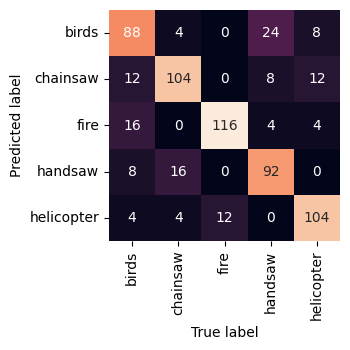

✔ Modèle sauvegardé dans : data/models/model_audio_svm.pickle

🎯 Accuracy : 0.75

📊 Classification report :

              precision    recall  f1-score   support

       birds       0.86      0.75      0.80         8
    chainsaw       0.57      0.50      0.53         8
        fire       0.89      1.00      0.94         8
     handsaw       1.00      0.75      0.86         8
  helicopter       0.55      0.75      0.63         8

    accuracy                           0.75        40
   macro avg       0.77      0.75      0.75        40
weighted avg       0.77      0.75      0.75        40



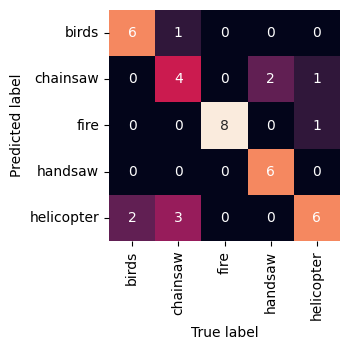

In [ ]:
import numpy as np
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------------------------------
# PARTIE 0 — Répertoires
# -------------------------------------------------------

fm_dir = "data/feature_matrices/"
model_dir = "data/models/"

os.makedirs(fm_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# -------------------------------------------------------
# PARTIE 1 — Charger les matrices sauvegardées
# -------------------------------------------------------

# feature_file = fm_dir + "feature_matrix_2D_aug.npy"
# label_file   = fm_dir + "labels_aug.npy"

# # Vérifier que les fichiers existent
# if not os.path.exists(feature_file) or not os.path.exists(label_file):
#     raise FileNotFoundError(
#         "\n❌ Les fichiers de features n'existent pas !\n"
#         f"Je cherche :\n - {feature_file}\n - {label_file}\n\n"
#         "➡️ Exécute d'abord la cellule qui crée X_aug et y_aug,\n"
#         "puis sauvegarde-les avec :\n\n"
#         "np.save(fm_dir + 'feature_matrix_2D_aug.npy', X_aug)\n"
#         "np.save(fm_dir + 'labels_aug.npy', y_aug)\n"
#     )

# print("✔ Chargement des features...")
# X = np.load(feature_file)
# y = np.load(label_file, allow_pickle=True)
# print("X shape :", X.shape)
# print("y shape :", y.shape)

print("✔ Chargement des données...")

try:
    X_train = np.load(fm_dir + 'X_train.npy')
    y_train = np.load(fm_dir + 'y_train.npy', allow_pickle=True)
    X_test  = np.load(fm_dir + 'X_test.npy')
    y_test  = np.load(fm_dir + 'y_test.npy', allow_pickle=True)
except FileNotFoundError:
    raise FileNotFoundError("❌ Les fichiers train/test n'existent pas. Lance le script de génération de données corrigé.")

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
# -------------------------------------------------------
# PARTIE 2 — Split / Normalisation / PCA
# -------------------------------------------------------

# Mélange des données
X_train, y_train = shuffle(X_train, y_train, random_state=0)
X_test, y_test = shuffle(X_test, y_test, random_state=0)

# Normalisation
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm  = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.8, random_state=0)  # garde 95 % de la variance
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca  = pca.transform(X_test_norm)

print("✔ Dimension après PCA :", X_train_pca.shape)


# -------------------------------------------------------
# PARTIE 3 — Entraînement du modèle SVM
# -------------------------------------------------------

model = SVC(kernel="linear", C=0.01, gamma=0.01, class_weight="balanced",probability=True, random_state=0)
model.fit(X_train_pca, y_train)

print("✔ Modèle entraîné !")

y_train_test = model.predict(X_train_pca)
print("\n🎯 Accuracy train :", accuracy_score(y_train, y_train_test))
print("\n📊 Classification report train :\n")
print(classification_report(y_train, y_train_test))
show_confusion_matrix(y_train_test, y_train, classnames)

# -------------------------------------------------------
# PARTIE 4 — Sauvegarde du modèle complet
# -------------------------------------------------------

model_filename = "model_audio_svm.pickle"

with open(model_dir + model_filename, "wb") as f:
    pickle.dump({"scaler": scaler, "pca": pca, "model": model}, f)

print("✔ Modèle sauvegardé dans :", model_dir + model_filename)


# -------------------------------------------------------
# PARTIE 5 — Évaluation
# -------------------------------------------------------

y_pred = model.predict(X_test_pca)

print("\n🎯 Accuracy :", accuracy_score(y_test, y_pred))
print("\n📊 Classification report :\n")
print(classification_report(y_test, y_pred))

show_confusion_matrix(y_pred, y_test, classnames)


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the grid (The values you want to test)
param_grid = {
    'C': [0.1, 1, 10, 100],        # The Grid Search will swap these in for you
    'gamma': ['scale', 'auto', 0.01, 0.1],
    # You can even test kernels if you want!
    'kernel': ['rbf'] 
}

# 2. Setup GridSearch
# Notice inside SVC(): I removed C and gamma. 
# I kept random_state=0 because that should stay constant.
grid_search = GridSearchCV(
    estimator=SVC(random_state=0, class_weight="balanced", probability=True),
    param_grid=param_grid,
    cv=5,          # 5-Fold Cross Validation
    n_jobs=-1,     # Use all CPU cores
    verbose=2
)

# 3. Train (This replaces model.fit)
grid_search.fit(X_train_pca, y_train)

# 4. Get the best C and gamma automatically
print(f"Best Params: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# import numpy as np
# import pickle
# import os
# import pandas as pd  # Added for CSV export

# from sklearn.model_selection import train_test_split
# from sklearn.utils import shuffle
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# # Ensure you have your plotting function available
# from src.classification.utils.plots import show_confusion_matrix 

# # -------------------------------------------------------
# # PARTIE 0 — Répertoires
# # -------------------------------------------------------

# fm_dir = "data/feature_matrices/"
# model_dir = "data/models/"

# os.makedirs(fm_dir, exist_ok=True)
# os.makedirs(model_dir, exist_ok=True)

# # -------------------------------------------------------
# # PARTIE 1 — Charger les matrices sauvegardées
# # -------------------------------------------------------

# print("✔ Chargement des données...")

# try:
#     X_train = np.load(fm_dir + 'X_train.npy')
#     y_train = np.load(fm_dir + 'y_train.npy', allow_pickle=True)
#     X_test  = np.load(fm_dir + 'X_test.npy')
#     y_test  = np.load(fm_dir + 'y_test.npy', allow_pickle=True)
# except FileNotFoundError:
#     raise FileNotFoundError("❌ Les fichiers train/test n'existent pas. Lance le script de génération de données.")

# print(f"Train shape : {X_train.shape}")
# print(f"Test shape  : {X_test.shape}")

# # -------------------------------------------------------
# # [NOUVEAU] RECONSTRUCTION DES NOMS DE FICHIERS
# # -------------------------------------------------------
# # Comme X_test.npy a été créé dans l'ordre des classes avec un seed fixe (42),
# # on peut retrouver quels fichiers correspondent à X_test avant le mélange.

# print("🔄 Reconstruction des noms de fichiers de test...")
# filenames_test_raw = []

# # ⚠️ 'myds' et 'classnames' doivent exister dans votre environnement !
# # Si ce n'est pas le cas, décommentez les lignes ci-dessous pour recharger votre dataset :
# # myds = AudioDataset(...) 
# # classnames = myds.classes


# # -------------------------------------------------------
# # PARTIE 2 — Split / Normalisation / PCA
# # -------------------------------------------------------

# # Mélange des données
# # ON AJOUTE filenames_test_raw DANS LE SHUFFLE POUR GARDER LA CORRESPONDANCE
# X_train, y_train = shuffle(X_train, y_train, random_state=0)
# X_test, y_test, filenames_test = shuffle(X_test, y_test, filenames_test_raw, random_state=0)

# # --- Sauvegarde du CSV "Ground Truth" ---
# # C'est ce fichier que vous utiliserez pour savoir quel son jouer
# df_gt = pd.DataFrame({
#     "filename": filenames_test,
#     "label": y_test
# })

# # Sauvegarde pour vous (pour lire quel fichier jouer)
# csv_path = fm_dir + "test_files_groundtruth.csv"
# df_gt.to_csv(csv_path, index=False)

# # Sauvegarde d'un fichier compatible direct avec uart-reader (juste les labels)
# df_gt["label"].to_csv("ground_truth.csv", index=False, header=False)

# print(f"✔ Fichier Ground Truth créé : {csv_path}")
# print(f"✔ Fichier labels pour UART créé : ground_truth.csv")


# # Normalisation
# scaler = StandardScaler()
# X_train_norm = scaler.fit_transform(X_train)
# X_test_norm  = scaler.transform(X_test)

# # PCA
# pca = PCA(n_components=0.95, random_state=0)  # garde 95 % de la variance
# X_train_pca = pca.fit_transform(X_train_norm)
# X_test_pca  = pca.transform(X_test_norm)

# print("✔ Dimension après PCA :", X_train_pca.shape)


# # -------------------------------------------------------
# # PARTIE 3 — Entraînement du modèle SVM
# # -------------------------------------------------------

# # Définir best_C si non défini
# best_C = 1.0 

# model = SVC(kernel="rbf", C=best_C, gamma="scale", class_weight="balanced", probability=True, random_state=0)
# model.fit(X_train_pca, y_train)

# print("✔ Modèle entraîné !")

# y_train_test = model.predict(X_train_pca)
# print("\n🎯 Accuracy train :", accuracy_score(y_train, y_train_test))
# print("\n📊 Classification report train :\n")
# print(classification_report(y_train, y_train_test))
# # show_confusion_matrix(y_train_test, y_train, classnames)

# # -------------------------------------------------------
# # PARTIE 4 — Sauvegarde du modèle complet
# # -------------------------------------------------------

# model_filename = "model_audio_svm_class.pickle"

# with open(model_dir + model_filename, "wb") as f:
#     pickle.dump({"scaler": scaler, "pca": pca, "model": model}, f)

# print("✔ Modèle sauvegardé dans :", model_dir + model_filename)


# # -------------------------------------------------------
# # PARTIE 5 — Évaluation
# # -------------------------------------------------------

# y_pred = model.predict(X_test_pca)

# print("\n🎯 Accuracy :", accuracy_score(y_test, y_pred))
# print("\n📊 Classification report :\n")
# print(classification_report(y_test, y_pred))

# show_confusion_matrix(y_pred, y_test, classnames)

<font size=5 color=#009999> 2.8. Debriefing </font> <br>
**Questions** : 

1) from what we have done in this notebook, can you already identify some weaknesses in the feature vector computation and classification pipeline? You can make a list here below, and eventually write some short ideas for improvement. This will help you later :)
2) Do you remember what is the time duration of a feature vector? What happens if no sound is produced during the acquisition time of a feature vector?

In [ ]:
### TO COMPLETE
# Answer the question above